# IO ZH2019 Debug

Thin debug notebook for the manually built single-soma IO cell. Toggle channels in the config cell, run both NEURON and BrainCell, then inspect soma voltage and gate traces.

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import brainunit as u
from neuron import h

def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.neuron_compare.cell.io_zh2019.debug.io_parameters import (
    DEFAULT_NRNMECH_PATH,
    IOConfig,
    IOToggles,
    load_io19_params,
)
from examples.neuron_compare.cell.io_zh2019.debug.io_neuron_debug import IO as NeuronIO
from examples.neuron_compare.cell.io_zh2019.debug.io_braincell_debug import IO as BrainCellIO

import braincell
from braincell import mech
from braincell.filter import at
import brainstate

brainstate.environ.set(precision=64)
print("braincell import:", braincell.__file__)
print("NEURON mechanisms:", DEFAULT_NRNMECH_PATH)


--No graphics will be displayed.


braincell import: /home/swl/braincell-ion_dyn/braincell/__init__.py
NEURON mechanisms: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/IO/x86_64/.libs/libnrnmech.so


In [2]:
params = load_io19_params()

# Edit these booleans for channel isolation. Start with leak-only for a stable smoke test.
toggles = IOToggles(
    leak=True,
    na=True,
    kdr=True,
    ca=True,
    hcn=True,
)

config = IOConfig(toggles=toggles, temperature_celsius=36.0, v_init_mV=-65.0)

dt_ms = 0.05
duration_ms = 100.0
delay_ms = 10.0
stim_dur_ms = 80.0
amp_nA = 0.01

gate_probe_config = {
    "na": True,
    "kdr": True,
    "ca": True,
    "hcn": True,
}

pd.Series({
    "toggles": config.toggles,
    "dt_ms": dt_ms,
    "duration_ms": duration_ms,
    "delay_ms": delay_ms,
    "stim_dur_ms": stim_dur_ms,
    "amp_nA": amp_nA,
})


toggles        IOToggles(leak=True, na=True, kdr=True, ca=Tru...
dt_ms                                                       0.05
duration_ms                                                100.0
delay_ms                                                    10.0
stim_dur_ms                                                 80.0
amp_nA                                                      0.01
dtype: object

In [3]:
neuron_io = NeuronIO(params=params, config=config, nrnmech_path=DEFAULT_NRNMECH_PATH).build()
braincell_io = BrainCellIO(params=params, config=config).build()

display(pd.Series(neuron_io.summary()))
display(pd.Series(braincell_io.summary()))
display(neuron_io.branch_table())
display(braincell_io.branch_table())


backend                                                          neuron
manual_soma                                                        True
nrnmech_path          /home/swl/braincell-ion_dyn/examples/neuron_co...
toggles               {'leak': True, 'na': True, 'kdr': True, 'ca': ...
branch_counts                               {'n_soma': 1, 'n_total': 1}
compartment_counts                                  {'n_total_nseg': 1}
enabled_mechanisms         {'soma': ['leak', 'na', 'kdr', 'ca', 'hcn']}
ion_status            {'ena_enabled': True, 'ek_enabled': True, 'ca_...
dtype: object

backend                                                             braincell
manual_soma                                                              True
ion_channel_update_order                                               family
toggles                     {'leak': True, 'na': True, 'kdr': True, 'ca': ...
branch_counts                                     {'n_soma': 1, 'n_total': 1}
compartment_counts                                        {'n_total_nseg': 1}
enabled_mechanisms               {'soma': ['leak', 'na', 'kdr', 'ca', 'hcn']}
ion_status                  {'na_enabled': True, 'k_enabled': True, 'ca_ch...
dtype: object

,branch_index,branch_name,branch_type,length_um,diam_um,nseg
0,0,soma[0],soma,20.0,20.0,1


,branch_index,branch_name,branch_type,length_um,diam_um,nseg
0,0,soma,soma,20.0,20.0,1


In [4]:
nrn_voltage_probes = neuron_io.attach_voltage_probes(all_compartments=True, soma=True)
bc_voltage_probes = braincell_io.attach_voltage_probes(all_compartments=True, soma=True)

def attach_gate_diagnostics(neuron_io, braincell_io, toggles, gate_probe_config):
    handles = {}
    nrn_seg = neuron_io.root_soma(0.5)
    specs = {
        "na": ("Na_ZH19_IO", "Na_soma", ("m", "h")),
        "kdr": ("Kdr_ZH19_IO", "Kdr_soma", ("n",)),
        "ca": ("Ca_ZH19_IO", "Ca_soma", ("h",)),
        "hcn": ("HCN_ZH19_IO", "HCN_soma", ("q",)),
    }
    for logical_name, (nrn_mech_name, bc_mech_name, gate_names) in specs.items():
        if not getattr(toggles, logical_name) or not gate_probe_config.get(logical_name, False):
            continue
        nrn_mech = getattr(nrn_seg, nrn_mech_name)
        for gate_name in gate_names:
            key = f"{logical_name}_{gate_name}"
            handles[f"{key}_neuron"] = h.Vector().record(getattr(nrn_mech, f"_ref_{gate_name}"))
            trace_name = f"{key}_braincell"
            braincell_io.cell.place(
                at("soma", 0.5),
                mech.MechanismProbe(mechanism=bc_mech_name, field=gate_name, name=trace_name),
            )
            handles[f"{key}_braincell_trace"] = trace_name
    return handles

gate_handles = attach_gate_diagnostics(neuron_io, braincell_io, toggles, gate_probe_config)
sorted(gate_handles)


['ca_h_braincell_trace',
 'ca_h_neuron',
 'hcn_q_braincell_trace',
 'hcn_q_neuron',
 'kdr_n_braincell_trace',
 'kdr_n_neuron',
 'na_h_braincell_trace',
 'na_h_neuron',
 'na_m_braincell_trace',
 'na_m_neuron']

In [5]:
stim = h.IClamp(neuron_io.root_soma(0.5))
stim.delay = delay_ms
stim.dur = stim_dur_ms
stim.amp = amp_nA

h.cvode_active(0)
h.dt = dt_ms
h.steps_per_ms = 1.0 / dt_ms
h.celsius = config.temperature_celsius
h.v_init = config.v_init_mV
h.finitialize(h.v_init)
h.tstop = duration_ms
h.run()

braincell_io.cell.place(
    at("soma", 0.5),
    mech.CurrentClamp(delay=delay_ms * u.ms, durations=stim_dur_ms * u.ms, amplitudes=amp_nA * u.nA),
)
braincell_io.cell.init_state()
braincell_io.cell.reset_state()
bc_run = braincell_io.cell.run(dt=dt_ms * u.ms, duration=duration_ms * u.ms)

nrn_v = neuron_io.collect_voltage_results(nrn_voltage_probes)
bc_v = braincell_io.collect_voltage_results(bc_voltage_probes, bc_run)
reference_time_ms = np.arange(0.0, duration_ms + 0.5 * dt_ms, dt_ms)
braincell_time_ms = np.asarray((bc_run.time + dt_ms * u.ms).to_decimal(u.ms), dtype=float).reshape(-1)
{
    "neuron_soma_points": int(nrn_v["soma_voltage_mV"].shape[0]),
    "braincell_soma_points": int(bc_v["soma_voltage_mV"].shape[0]),
    "braincell_time_points": int(braincell_time_ms.shape[0]),
}


{'neuron_soma_points': 2001,
 'braincell_soma_points': 2000,
 'braincell_time_points': 2000}

In [6]:
def trim_neuron_trace(values, target_len):
    arr = np.asarray(values, dtype=float).reshape(-1)
    if arr.shape[0] == target_len + 1:
        return arr[1:]
    return arr[:target_len]

braincell_soma = np.asarray(bc_v["soma_voltage_mV"], dtype=float).reshape(-1)
neuron_soma = trim_neuron_trace(nrn_v["soma_voltage_mV"], braincell_soma.shape[0])
time_ms = braincell_time_ms[:braincell_soma.shape[0]]
n = min(neuron_soma.shape[0], braincell_soma.shape[0], time_ms.shape[0])
neuron_soma = neuron_soma[:n]
braincell_soma = braincell_soma[:n]
time_ms = time_ms[:n]
delta_soma = braincell_soma - neuron_soma

summary = {
    "voltage_rmse_mV": float(np.sqrt(np.mean(delta_soma ** 2))),
    "voltage_max_abs_mV": float(np.max(np.abs(delta_soma))),
    "voltage_mean_abs_mV": float(np.mean(np.abs(delta_soma))),
}

gate_pairs = {}
for key in sorted(k[:-7] for k in gate_handles if k.endswith("_neuron")):
    nrn_key = f"{key}_neuron"
    bc_key = f"{key}_braincell_trace"
    if bc_key not in gate_handles:
        continue
    neuron_gate = trim_neuron_trace(gate_handles[nrn_key], n)[:n]
    braincell_gate = np.asarray(bc_run.traces[gate_handles[bc_key]], dtype=float).reshape(-1)[:n]
    m = min(neuron_gate.shape[0], braincell_gate.shape[0], n)
    gate_pairs[key] = (time_ms[:m], neuron_gate[:m], braincell_gate[:m])
    diff = braincell_gate[:m] - neuron_gate[:m]
    summary[f"{key}_rmse"] = float(np.sqrt(np.mean(diff ** 2)))
    summary[f"{key}_max_abs"] = float(np.max(np.abs(diff)))

pd.Series(summary, dtype=float)


voltage_rmse_mV        4.180528e-10
voltage_max_abs_mV     7.746686e-09
voltage_mean_abs_mV    1.010373e-10
ca_h_rmse              7.949865e-15
ca_h_max_abs           2.195466e-14
hcn_q_rmse             3.071938e-14
hcn_q_max_abs          7.300271e-13
kdr_n_rmse             2.614030e-12
kdr_n_max_abs          3.646428e-11
na_h_rmse              1.846067e-13
na_h_max_abs           1.335265e-12
na_m_rmse              5.214322e-12
na_m_max_abs           8.463341e-11
dtype: float64

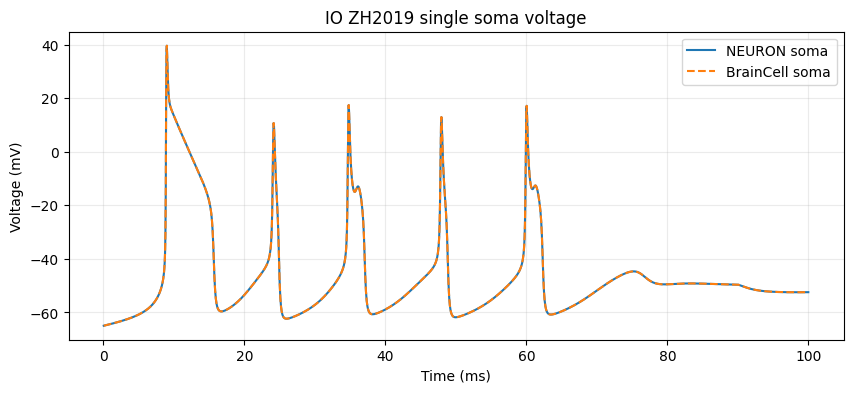

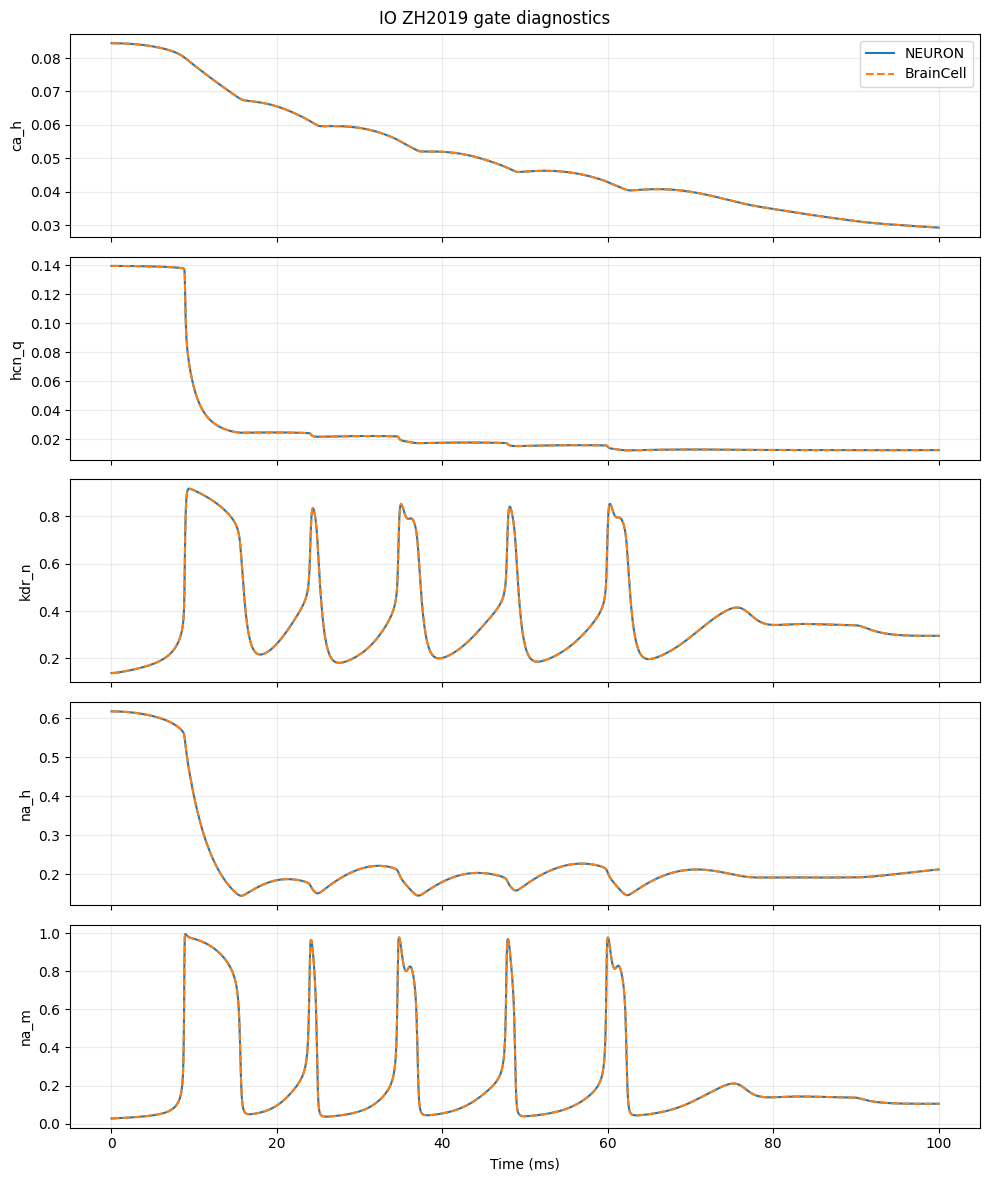

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_ms, neuron_soma, label="NEURON soma")
ax.plot(time_ms, braincell_soma, label="BrainCell soma", linestyle="--")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (mV)")
ax.set_title("IO ZH2019 single soma voltage")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

if gate_pairs:
    fig, axes = plt.subplots(len(gate_pairs), 1, figsize=(10, 2.4 * len(gate_pairs)), sharex=True)
    if len(gate_pairs) == 1:
        axes = [axes]
    for ax, (key, (gate_time_ms, neuron_gate, braincell_gate)) in zip(axes, gate_pairs.items()):
        ax.plot(gate_time_ms, neuron_gate, label="NEURON")
        ax.plot(gate_time_ms, braincell_gate, label="BrainCell", linestyle="--")
        ax.set_ylabel(key)
        ax.grid(alpha=0.25)
    axes[-1].set_xlabel("Time (ms)")
    axes[0].legend()
    fig.suptitle("IO ZH2019 gate diagnostics")
    fig.tight_layout()
    plt.show()


In [8]:
# Optional cleanup when re-running cells in the same kernel.
# neuron_io.cleanup()
